# RTMA Fuel Moisture Analysis — Local Pipeline

Consumes the NWS RTMA hourly pyrome-mean CSVs exported from GEE
(see `00b_RTMA-EMC.ipynb`) and produces per-pyrome dead and live
fuel moisture for FlamMap scenario inputs.

**Pipeline summary**
1. Load all yearly RTMA CSVs → hourly frame
2. NFDRS78 exponential lag (hourly dt=1 h) → FM1 / FM10 / FM100
3. Collapse to daily peak-hour (14:00 LST)
4. GSI-based live FM → FM_herb / FM_woody
5. Join dead + live into one daily frame
6. QA plots (time series, seasonal climatology, precip rebound)
7. FlamMap scenario cache via `build_flammap_scenario_cache(dead_fm_source='rtma')`
8. Summary table

**Sources:** `fb_tools.weather.rtma`, `fb_tools.weather.gridmet`, `fb_tools.weather.hrrr`

**Live FM calibration caveat:** Jolly et al. (2005) GSI thresholds were
calibrated for temperate/boreal vegetation. In CO's semi-arid fire season,
VPD routinely exceeds the 4100 Pa 'limiting' bound, compressing GSI toward
zero and keeping FM_herb near dormant (30%). This is a known limitation
of the approach; see `CLAUDE.md` GridMET ERC climatology notes.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from fb_tools.weather.rtma import (
    load_rtma_csv,
    build_rtma_dead_fm,
    build_rtma_live_fm,
    collapse_to_peak_hour,
)
from fb_tools.weather.gridmet import load_gridmet_csv, build_flammap_scenario_cache
from fb_tools.weather.hrrr import wind_percentiles_from_cell_cache

# ── paths (relative to this notebook's location: code/notebooks/) ──────────
REPO = Path("../..").resolve()
RTMA_DIR    = REPO / "data/weather/pyrome_emc/RTMA_EMC"
GRIDMET_CSV = REPO / "data/tabular/raw/weather/gridmet_clim_CO_pyromes.csv"
WIND_DIR    = REPO / "data/weather/pyrome_wind"
BASELINE_DIR = REPO / "data/weather/flammap"          # existing GridMET-based JSONs
OUT_DIR     = REPO / "data/weather/flammap_rtma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── constants ───────────────────────────────────────────────────────────────
CO_LAT  = 39.5          # representative latitude for CO pyromes
TZ_OFF  = -7.0          # MST year-round (RAWS/WIMS convention)
PEAK_HR = 14            # 14:00 LST peak fire hour

CO_PYROME_IDS = [42, 43, 45, 46, 47, 52, 53, 56, 128]

print(f"RTMA dir  : {RTMA_DIR}")
print(f"Output dir: {OUT_DIR}")
print(f"CSV files : {len(list(RTMA_DIR.glob('*.csv')))}")

RTMA dir  : /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/pyrome_emc/RTMA_EMC
Output dir: /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/flammap_rtma
CSV files : 15


## 1. Load RTMA hourly data

In [2]:
rtma_hr = load_rtma_csv(RTMA_DIR)

print(f"Shape          : {rtma_hr.shape}")
print(f"Date range     : {rtma_hr['datetime_utc'].min()} → {rtma_hr['datetime_utc'].max()}")
print(f"Pyromes        : {sorted(rtma_hr['pyrome_id'].unique())}")
print(f"Null counts    :")
print(rtma_hr.isnull().sum().to_string())

rtma_hr.head(3)

Shape          : (683676, 7)
Date range     : 2011-04-01 00:00:00 → 2025-10-31 23:00:00
Pyromes        : [np.int64(42), np.int64(43), np.int64(45), np.int64(46), np.int64(47), np.int64(52), np.int64(53), np.int64(56), np.int64(128)]
Null counts    :
pyrome_id       0
datetime_utc    0
tmp_f           0
rh_pct          0
emc_pct         0
vpd_pa          0
pcp_mm_hr       0


,pyrome_id,datetime_utc,tmp_f,rh_pct,emc_pct,vpd_pa,pcp_mm_hr
0,42,2011-04-01 00:00:00,68.930872,16.861351,3.895286,2072.842004,0.0
1,42,2011-04-01 01:00:00,66.160823,18.870537,4.272876,1848.623699,0.0
2,42,2011-04-01 02:00:00,60.666887,22.239487,4.893629,1458.591116,0.0


In [3]:
print(rtma_hr.describe())

           pyrome_id                   datetime_utc          tmp_f  \
count  683676.000000                         683676  683676.000000   
mean       56.888889  2018-08-09 07:10:13.332631552      59.277463   
min        42.000000            2011-04-01 00:00:00      -7.775347   
25%        45.000000            2014-10-09 00:45:00      48.163114   
50%        47.000000            2018-08-06 23:30:00      59.468904   
75%        53.000000            2022-06-03 07:15:00      70.560002   
max       128.000000            2025-10-31 23:00:00     110.099267   
std        25.536243                            NaN      15.955959   

              rh_pct        emc_pct         vpd_pa      pcp_mm_hr  
count  683676.000000  683676.000000  683676.000000  683676.000000  
mean       48.329581       9.961658    1186.650860       0.056180  
min         3.359808       0.793163       0.000000       0.000000  
25%        29.893385       6.043329     427.528561       0.000000  
50%        46.327864       8.

---
## Dead FM — hourly NFDRS78 time-lag

Runs `calc_lagged_fm` at `dt_hr=1` against the per-pixel-averaged EMC series.
Equivalent to FireFamilyPlus BNDRYT integration against hourly RAWS:
- FM1: α ≈ 0.632/hr (1-hr lag; tracks EMC almost instantly)
- FM10: α ≈ 0.095/hr (10-hr lag; ~daily smoothing)
- FM100: α ≈ 0.010/hr (100-hr lag; integrates ~22 days of history)

Precip: `stall` mode — during hours with pcp > 0.25 mm/hr the EMC input is
forced to the saturation ceiling (35% for FM10, 50% for FM100).

In [4]:
rtma_dead = build_rtma_dead_fm(
    rtma_hr,
    precip_mode="stall",
    precip_threshold_mm_hr=0.25,
)

print("Dead FM summary (all pyromes × all fire-season hours):")
rtma_dead[["FM1", "FM10", "FM100"]].describe().round(2)

Dead FM summary (all pyromes × all fire-season hours):


,FM1,FM10,FM100
count,683676.00,683676.00,683676.00
mean,9.96,11.42,12.41
std,4.94,6.03,6.18
min,0.81,1.48,2.53
25%,6.11,7.11,8.68
50%,8.94,9.90,11.44
75%,12.96,14.23,14.69
max,25.74,35.00,50.00


## 3. Collapse to daily peak-hour (14:00 LST)

Samples the row at 14:00 MST (= 21:00 UTC) to match the
RAWS / FireFamilyPlus 13:00 LST reporting convention.

In [5]:
rtma_peak = collapse_to_peak_hour(
    rtma_dead,
    peak_hour_local=PEAK_HR,
    tz_offset_hours=TZ_OFF,
    value_cols=("FM1", "FM10", "FM100", "tmp_f", "rh_pct", "pcp_mm_hr"),
)

print(f"Daily peak-hour rows : {len(rtma_peak):,}")
print(f"Expected (≈ 214 d × 15 yr × 9 pyromes) : {214 * 15 * 9:,}")

# QA: each (pyrome, date) should have exactly one row
dup_check = rtma_peak.duplicated(subset=["pyrome_id", "date"]).sum()
print(f"Duplicate (pyrome, date) rows : {dup_check}  ← expect 0")

# Check for missing peak-hour coverage (any pyromes × dates without a 14:00 row)
n_pyromes = rtma_peak["pyrome_id"].nunique()
n_dates   = rtma_peak["date"].nunique()
print(f"Pyromes : {n_pyromes} | Unique dates : {n_dates} | Total : {len(rtma_peak):,}")

rtma_peak.head(3)

Daily peak-hour rows : 28,467
Expected (≈ 214 d × 15 yr × 9 pyromes) : 28,890
Duplicate (pyrome, date) rows : 0  ← expect 0
Pyromes : 9 | Unique dates : 3163 | Total : 28,467


,pyrome_id,date,doy,FM1,FM10,FM100,tmp_f,rh_pct,pcp_mm_hr
0,42,2011-04-01,91,3.442790,5.450727,4.309690,72.996803,13.594324,0.000000
1,42,2011-04-02,92,3.576907,5.031261,4.478123,75.612523,15.016083,0.000000
2,42,2011-04-03,93,8.210084,7.482613,4.925147,49.024611,37.593607,0.022574


## 4. Live FM — GSI-based herb/woody

Aggregates hourly RTMA to daily:
- **Tmin**: daily minimum temperature (all 24 hrs)
- **VPD_day**: mean over daytime hours [06:00, 18:00) LST
- **Photoperiod**: `calc_daylength(doy, lat_deg=39.5)`

GSI maps linearly to FM_herb ∈ [30%, 250%] and FM_woody ∈ [60%, 200%].

In [6]:
rtma_live = build_rtma_live_fm(
    rtma_hr,
    lat_deg=CO_LAT,
    tz_offset_hours=TZ_OFF,
)

print("Live FM summary:")
rtma_live[["gsi", "FM_herb", "FM_woody"]].describe().round(2)

Live FM summary:


,gsi,FM_herb,FM_woody
count,28719.00,28719.00,28719.00
mean,0.59,106.93,108.96
std,0.29,76.27,48.53
min,0.00,30.00,60.00
25%,0.39,30.00,60.00
50%,0.64,91.59,99.19
75%,0.82,169.28,148.64
max,1.00,250.00,200.00


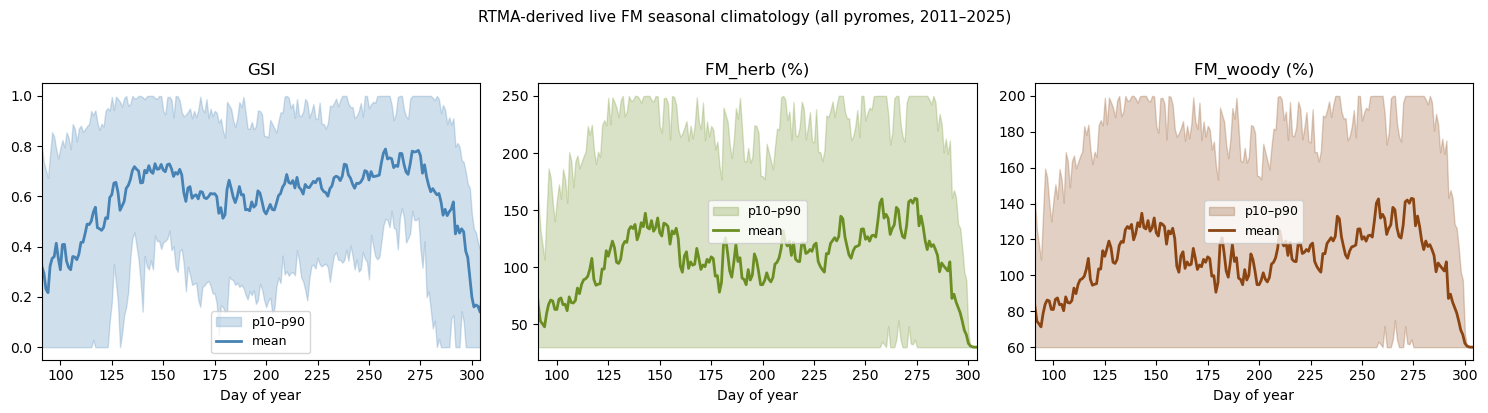

In [7]:
# Seasonal climatology of GSI and live FM
live_clim = (
    rtma_live.assign(doy=pd.to_datetime(rtma_live["date"]).dt.dayofyear)
             .groupby("doy")[["gsi", "FM_herb", "FM_woody"]]
             .agg(["mean", lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)])
)
live_clim.columns = ["_".join(c).replace("<lambda_0>", "p10").replace("<lambda_1>", "p90")
                     for c in live_clim.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, var, title, color in zip(
    axes,
    ["gsi", "FM_herb", "FM_woody"],
    ["GSI", "FM_herb (%)", "FM_woody (%)"],
    ["steelblue", "olivedrab", "saddlebrown"],
):
    ax.fill_between(
        live_clim.index,
        live_clim[f"{var}_p10"],
        live_clim[f"{var}_p90"],
        alpha=0.25, color=color, label="p10–p90",
    )
    ax.plot(live_clim.index, live_clim[f"{var}_mean"], color=color, lw=2, label="mean")
    ax.set_xlabel("Day of year")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(91, 304)

fig.suptitle("RTMA-derived live FM seasonal climatology (all pyromes, 2011–2025)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 5. Join dead + live into daily frame

In [8]:
rtma_daily = rtma_peak.merge(
    rtma_live[["pyrome_id", "date", "gsi", "FM_herb", "FM_woody"]],
    on=["pyrome_id", "date"],
    how="left",
)

print(f"Daily frame shape : {rtma_daily.shape}")
print(f"Null FM_herb rows : {rtma_daily['FM_herb'].isnull().sum()}")
rtma_daily.head(3)

Daily frame shape : (28467, 12)
Null FM_herb rows : 0


,pyrome_id,date,doy,FM1,FM10,FM100,tmp_f,rh_pct,pcp_mm_hr,gsi,FM_herb,FM_woody
0,42,2011-04-01,91,3.442790,5.450727,4.309690,72.996803,13.594324,0.000000,0.732275,132.200833,125.036893
1,42,2011-04-02,92,3.576907,5.031261,4.478123,75.612523,15.016083,0.000000,0.679257,108.872907,110.191850
2,42,2011-04-03,93,8.210084,7.482613,4.925147,49.024611,37.593607,0.022574,0.294474,30.000000,60.000000


In [9]:
# Optional: cache to parquet so we don't re-run the lag on every notebook run
parquet_path = OUT_DIR / "rtma_daily_fm.parquet"
rtma_daily.to_parquet(parquet_path, index=False)
print(f"Saved → {parquet_path}")

# To reload without re-running the lag:
# rtma_daily = pd.read_parquet(parquet_path)

Saved → /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/flammap_rtma/rtma_daily_fm.parquet


## 6. QA validation

Checks:
- FM ordering: FM1 < FM10 (peak-hour fine fuels drier than 10-hr)
- FM10 < FM100 on average (lag integration)
- Spring (Apr) wetter than summer (Jul–Aug) for FM100
- Precip rebound visible in FM100 time series

In [10]:
# ── QA 1: FM ordering check ─────────────────────────────────────────────────
fm_order_ok = (
    (rtma_daily["FM1"] <= rtma_daily["FM10"]).mean() * 100,
    (rtma_daily["FM10"] <= rtma_daily["FM100"]).mean() * 100,
)
print(f"FM1 ≤ FM10 on  {fm_order_ok[0]:.1f}% of days  (expect high — peak-hour fine fuels driest)")
print(f"FM10 ≤ FM100 on {fm_order_ok[1]:.1f}% of days  (expect high — lag integrates wetter periods)")

# ── QA 2: seasonal means by month ───────────────────────────────────────────
seasonal = (
    rtma_daily.assign(month=pd.to_datetime(rtma_daily["date"]).dt.month)
              .groupby("month")[["FM1", "FM10", "FM100"]]
              .mean()
              .round(2)
)
print("\nMonthly mean FM (all pyromes):")
seasonal.index = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"][:len(seasonal)]
print(seasonal.to_string())

FM1 ≤ FM10 on  98.6% of days  (expect high — peak-hour fine fuels driest)
FM10 ≤ FM100 on 72.3% of days  (expect high — lag integrates wetter periods)

Monthly mean FM (all pyromes):
      FM1   FM10  FM100
Apr  7.35  10.93  11.90
May  7.26  11.68  13.26
Jun  5.49   9.74  11.65
Jul  5.87  10.95  12.77
Aug  6.04  10.95  13.10
Sep  6.18  10.33  11.66
Oct  7.39  11.11  12.04


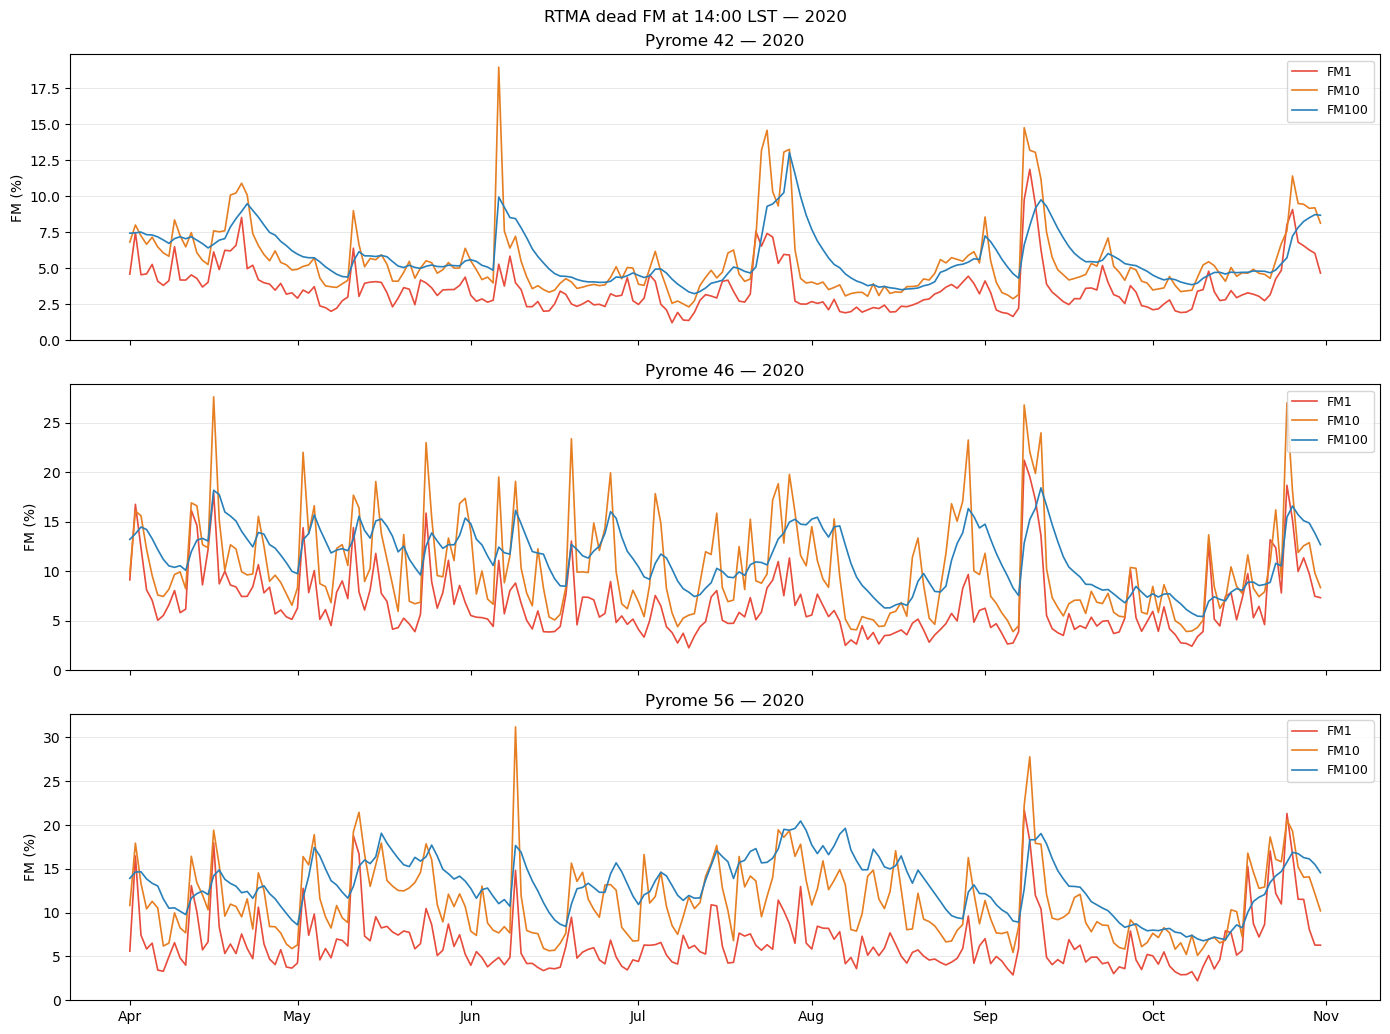

In [11]:
# ── QA 3: time-series plot for select pyromes — 2020 fire season ─────────────
PLOT_PYROMES = [42, 46, 56]   # range of pyromes — adjust as needed
PLOT_YEAR    = 2020

plot_df = rtma_daily[
    (rtma_daily["pyrome_id"].isin(PLOT_PYROMES))
    & (pd.to_datetime(rtma_daily["date"]).dt.year == PLOT_YEAR)
].copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, axes = plt.subplots(len(PLOT_PYROMES), 1, figsize=(14, 3.5 * len(PLOT_PYROMES)),
                          sharex=True)
colors = {"FM1": "#e74c3c", "FM10": "#e67e22", "FM100": "#2980b9"}

for ax, pid in zip(axes, PLOT_PYROMES):
    sub = plot_df[plot_df["pyrome_id"] == pid]
    for col, c in colors.items():
        ax.plot(sub["date"], sub[col], color=c, lw=1.2, label=col)
    ax.set_ylabel("FM (%)")
    ax.set_title(f"Pyrome {pid} — {PLOT_YEAR}")
    ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_ylim(0, None)
    ax.grid(axis="y", lw=0.4, alpha=0.5)

fig.suptitle(f"RTMA dead FM at 14:00 LST — {PLOT_YEAR}", fontsize=12)
plt.tight_layout()
plt.show()

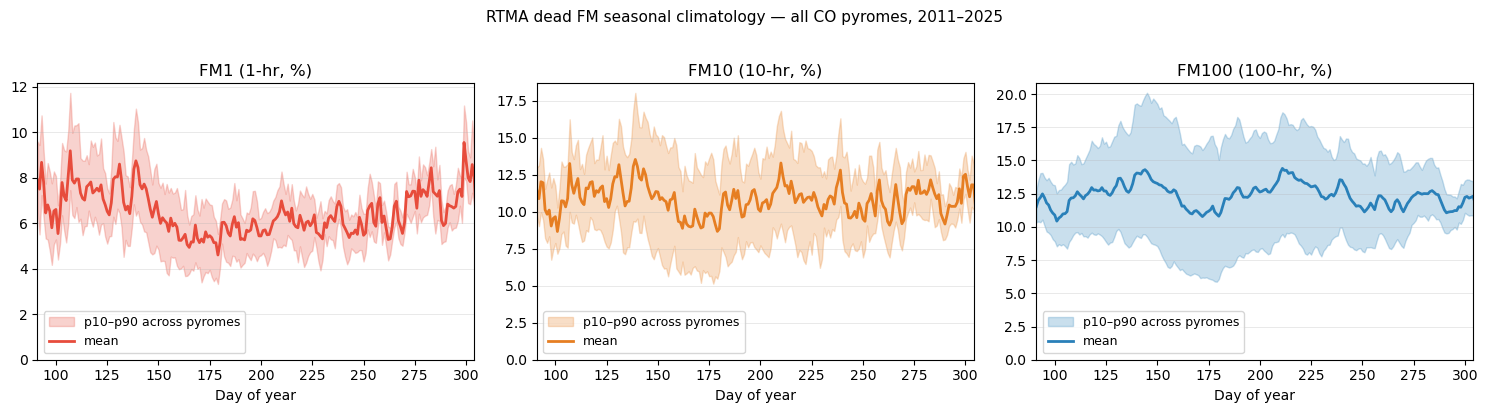

In [12]:
# ── QA 4: seasonal climatology by DOY — all pyromes, with IQR band ──────────
clim = (
    rtma_daily.assign(doy=pd.to_datetime(rtma_daily["date"]).dt.dayofyear)
              .groupby(["pyrome_id", "doy"])[["FM1", "FM10", "FM100"]]
              .mean()
              .groupby("doy")
              .agg(["mean",
                    lambda x: x.quantile(0.10),
                    lambda x: x.quantile(0.90)])
)
clim.columns = ["_".join(c).replace("<lambda_0>", "p10").replace("<lambda_1>", "p90")
                for c in clim.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, var, color, title in zip(
    axes,
    ["FM1", "FM10", "FM100"],
    ["#e74c3c", "#e67e22", "#2980b9"],
    ["FM1 (1-hr, %)", "FM10 (10-hr, %)", "FM100 (100-hr, %)"],
):
    ax.fill_between(
        clim.index, clim[f"{var}_p10"], clim[f"{var}_p90"],
        alpha=0.25, color=color, label="p10–p90 across pyromes",
    )
    ax.plot(clim.index, clim[f"{var}_mean"], color=color, lw=2, label="mean")
    ax.set_xlabel("Day of year")
    ax.set_title(title)
    ax.set_xlim(91, 304)
    ax.set_ylim(0, None)
    ax.legend(fontsize=9)
    ax.grid(axis="y", lw=0.4, alpha=0.5)

fig.suptitle("RTMA dead FM seasonal climatology — all CO pyromes, 2011–2025",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# ── QA 5: precip rebound check ───────────────────────────────────────────────
# On wet days (pcp > 0.25 mm/hr at peak hour) FM100 should be notably higher
# than the rolling average, confirming the 'stall' precip handling is active.
wet_mask = rtma_daily["pcp_mm_hr"] > 0.25
print(f"Wet peak-hour days : {wet_mask.sum():,} of {len(rtma_daily):,} ({wet_mask.mean()*100:.1f}%)")
print("\nMean FM on wet vs dry peak-hour days:")
print(
    rtma_daily.groupby(wet_mask)[["FM1", "FM10", "FM100"]]
              .mean()
              .rename(index={False: "Dry", True: "Wet"})
              .round(2)
)

Wet peak-hour days : 3,114 of 28,467 (10.9%)

Mean FM on wet vs dry peak-hour days:
            FM1  FM10  FM100
pcp_mm_hr                   
Dry        6.22   9.7  11.48
Wet        8.98  20.0  19.48


## 7. FlamMap scenario cache (RTMA FM sources)

ERC percentile bands are still GridMET-driven (unchanged contract).
Dead and live FM are replaced by RTMA-derived medians on the same ERC-band days.
Wind speed and direction come from the HRRR wind-cell cache.

In [14]:
# Load GridMET (columns auto-lowercased — PYROME → pyrome)
gridmet = load_gridmet_csv(GRIDMET_CSV)
print("GridMET columns :", list(gridmet.columns))
print(f"Pyromes          : {sorted(gridmet['pyrome'].unique())}")
gridmet.head(2)

  [load_gridmet_csv] 30,816 rows, 9 pyromes, years 2010–2025  [legacy flat]
GridMET columns : ['system:index', 'pyrome', 'date', 'doy', 'erc', 'fm100', 'fm1000', 'pr', 'rmax', 'rmin', 'vpd', 'year', '.geo', 'tmmx_f', 'tmmn_f', 'vpd_pa', 'ws_mph', 'wd_deg']
Pyromes          : [np.int64(42), np.int64(43), np.int64(45), np.int64(46), np.int64(47), np.int64(52), np.int64(53), np.int64(56), np.int64(128)]


,system:index,pyrome,date,doy,erc,fm100,fm1000,pr,rmax,rmin,vpd,year,.geo,tmmx_f,tmmn_f,vpd_pa,ws_mph,wd_deg
0,0_00000000000000000029,42,2010-04-01,91,47.876657,9.405033,13.404829,0.0,71.129282,34.623207,0.392185,2010,"{""type"":""MultiPoint"",""coordinates"":[]}",45.126126,25.968052,392.184514,14.713137,292.001129
1,0_0000000000000000002a,43,2010-04-01,91,39.870298,11.713263,14.839639,0.0,87.849365,44.118067,0.224720,2010,"{""type"":""MultiPoint"",""coordinates"":[]}",37.634056,19.638229,224.720312,14.085538,277.998749


In [15]:
# Load HRRR wind percentiles from pre-built wind-cell JSONs
wind_pcts = wind_percentiles_from_cell_cache(WIND_DIR)
print(f"Wind pyromes loaded : {sorted(wind_pcts.keys())}")

# Preview one entry
sample_key = str(CO_PYROME_IDS[0])
print(f"\nPyrome {sample_key} wind speeds (mph):")
if sample_key in wind_pcts:
    print({k: round(v, 1) for k, v in wind_pcts[sample_key]["ws_mph"].items()})

  [wind_percentiles_from_cell_cache] 10 pyromes × 5 percentiles
Wind pyromes loaded : ['128', '42', '43', '45', '46', '47', '52', '53', '56', 'Pyrome']

Pyrome 42 wind speeds (mph):
{'p25': 7.8, 'p50': 12.0, 'p75': 16.2, 'p90': 19.9, 'p97': 24.6}


In [16]:
scenarios = build_flammap_scenario_cache(
    gridmet,
    pyrome_col="pyrome",
    lat_deg=CO_LAT,
    wind_percentiles=wind_pcts,
    wind_direction=-2,          # FlamMap downhill convention
    dead_fm_source="rtma",
    live_fm_source="rtma",
    rtma_daily_df=rtma_daily,
    rtma_pyrome_col="pyrome_id",
    rtma_date_col="date",
    out_dir=OUT_DIR,
)

print(f"\nScenario cache written → {OUT_DIR}")
print(f"Pyromes: {list(scenarios.keys())}")

  [gridmet] Wrote pyrome_42_flammap.json
  [gridmet] Wrote pyrome_43_flammap.json
  [gridmet] Wrote pyrome_45_flammap.json
  [gridmet] Wrote pyrome_46_flammap.json
  [gridmet] Wrote pyrome_47_flammap.json
  [gridmet] Wrote pyrome_52_flammap.json
  [gridmet] Wrote pyrome_53_flammap.json
  [gridmet] Wrote pyrome_56_flammap.json
  [gridmet] Wrote pyrome_128_flammap.json
  [build_flammap_scenario_cache] 9 pyromes × 5 scenarios (±0.025 ERC band, wind=external, dead_fm=rtma, live_fm=rtma)

Scenario cache written → /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper/data/weather/flammap_rtma
Pyromes: ['42', '43', '45', '46', '47', '52', '53', '56', '128']


In [17]:
# Spot-check: print scenario table for one pyrome
SPOT_PYROME = "46"
spot = scenarios[SPOT_PYROME]["scenarios"]
cols = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody", "WIND_SPEED", "erc_center"]
rows = []
for pkey, vals in spot.items():
    rows.append({"pct": pkey, **{c: vals.get(c) for c in cols}})
spot_df = pd.DataFrame(rows).set_index("pct")
print(f"\nPyrome {SPOT_PYROME} RTMA scenarios:")
print(spot_df.to_string())


Pyrome 46 RTMA scenarios:
     FM_1hr  FM_10hr  FM_100hr  FM_herb  FM_woody  WIND_SPEED  erc_center
pct                                                                      
p25     8.5     13.8      15.1    170.6     149.5         8.1        38.0
p50     6.5     10.4      13.2    135.7     127.3        12.3        48.0
p75     5.1      8.9      11.2    123.3     119.4        17.0        58.8
p90     4.5      7.4      10.1    114.7     113.9        21.5        67.0
p97     3.8      6.0       7.9     86.0      95.6        27.0        74.0


In [18]:
# ── Compare RTMA vs GridMET baseline FM for the same pyrome ──────────────────
baseline_path = BASELINE_DIR / f"pyrome_{SPOT_PYROME}_flammap.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline = json.load(f)["scenarios"]

    fm_cols = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody"]
    comparison_rows = []
    for pkey in sorted(spot.keys()):
        if pkey not in baseline:
            continue
        row = {"pct": pkey}
        for c in fm_cols:
            row[f"{c}_rtma"]    = round(spot[pkey].get(c, float("nan")), 1)
            row[f"{c}_gridmet"] = round(baseline[pkey].get(c, float("nan")), 1)
            row[f"{c}_delta"]   = round(
                row[f"{c}_rtma"] - row[f"{c}_gridmet"], 1
            )
        comparison_rows.append(row)

    comp = pd.DataFrame(comparison_rows).set_index("pct")
    print(f"Pyrome {SPOT_PYROME} — RTMA vs GridMET FM delta (RTMA − GridMET):")
    delta_cols = [f"{c}_delta" for c in fm_cols]
    print(comp[delta_cols].to_string())
else:
    print(f"No baseline JSON found at {baseline_path} — skipping comparison.")

Pyrome 46 — RTMA vs GridMET FM delta (RTMA − GridMET):
     FM_1hr_delta  FM_10hr_delta  FM_100hr_delta  FM_herb_delta  FM_woody_delta
pct                                                                            
p25           2.4            0.6            -7.9           21.4           -50.5
p50           1.6            1.2            -3.2           28.9           -20.6
p75           1.0            1.2            -0.5           47.3            14.1
p90           1.0            0.6             0.7           53.7            29.4
p97           0.9            0.2             0.7           39.2            30.8


## 8. Summary table

Per-pyrome FM at p50 (median danger) and p90 (high danger) scenarios.

In [19]:
fm_cols = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody"]
summary_rows = []
for pid, cache in scenarios.items():
    for pkey in ["p90", "p97"]:
        if pkey not in cache.get("scenarios", {}):
            continue
        vals = cache["scenarios"][pkey]
        row = {"pyrome": int(pid), "pct": pkey}
        for c in fm_cols:
            row[c] = round(vals.get(c, float("nan")), 1)
        summary_rows.append(row)

summary = (
    pd.DataFrame(summary_rows)
      .sort_values(["pct", "pyrome"])
      .set_index(["pct", "pyrome"])
)
print("RTMA-based FlamMap scenario FM — CO pyromes")
print(summary.to_string())

RTMA-based FlamMap scenario FM — CO pyromes
            FM_1hr  FM_10hr  FM_100hr  FM_herb  FM_woody
pct pyrome                                              
p90 42         2.6      4.0       4.5     30.0      60.0
    43         3.3      4.8       5.6     30.0      60.0
    45         4.2      6.7       7.7    132.1     125.0
    46         4.5      7.4      10.1    114.7     113.9
    47         4.0      6.2       7.1    102.6     106.2
    52         3.8      6.7       8.9     49.5      72.4
    53         4.2      7.3       9.9     30.0      60.0
    56         4.5      8.4      10.8     44.8      69.4
    128        3.7      6.1       7.2     51.0      73.4
p97 42         2.2      3.4       3.7     30.0      60.0
    43         2.8      4.1       4.6     30.0      60.0
    45         3.7      5.5       6.5     91.1      98.9
    46         3.8      6.0       7.9     86.0      95.6
    47         3.3      4.9       5.9     72.4      87.0
    52         3.2      5.7       7.9     30

## 9. Formal comparison: RAWS (FireFamilyPlus) vs RTMA scenarios

**Reference:** Rhea et al. (2024) CFRI-2414, Table 1.
Seven RAWS stations in the Denver Water South Platte watershed, CO.
Percentiles derived with FireFamilyPlus 5 from daily 1300 LST observations, 2000–2020.
**ERC percentile convention:** higher = drier conditions = lower FM.

| Aspect | RAWS / FireFamilyPlus | RTMA / this model |
|---|---|---|
| Input | Daily 1300 LST RAWS obs | Hourly pyrome-mean RTMA |
| Spatial scale | Single point | Pyrome-mean (thousands km²) |
| FM lag dt | 24 hr | 1 hr |
| ERC source | NFDRS78 from RAWS | GridMET GEE |
| Period | 2000–2020 | 2011–2025 |

Pyrome-mean spatial averaging is the primary driver of compressed FM variability
relative to point RAWS observations.

In [20]:
# ── Table 1 from Rhea et al. (2024) CFRI-2414 ─────────────────────────────
# Columns: station, erc_pct (25/50/90/97), FM1, FM10, FM100, FM_herb, FM_woody
TABLE1_ROWS = [
    # Harbison Meadow (Clear Creek area → pyrome 42)
    ("Harbison Meadow", 42, 25,  9.1, 10.7, 17.2,  96, 121),
    ("Harbison Meadow", 42, 50,  5.6,  7.4, 14.6,  40,  78),
    ("Harbison Meadow", 42, 90,  3.0,  4.7, 10.5,  30,  70),
    ("Harbison Meadow", 42, 97,  2.2,  3.8,  8.9,  30,  70),
    # Gunsight (Pike NF → pyrome 43)
    ("Gunsight",        43, 25,  7.9,  9.0, 13.5,  56,  92),
    ("Gunsight",        43, 50,  4.8,  6.0, 10.1,  35,  63),
    ("Gunsight",        43, 90,  2.3,  3.3,  5.9,  30,  60),
    ("Gunsight",        43, 97,  0.7,  1.4,  3.6,  30,  60),
    # Soda Creek (Pike NF area → pyrome 43)
    ("Soda Creek",      43, 25,  8.8, 10.1, 15.8,  62, 102),
    ("Soda Creek",      43, 50,  5.1,  6.7, 12.3,  35,  70),
    ("Soda Creek",      43, 90,  2.8,  4.0,  7.6,  30,  70),
    ("Soda Creek",      43, 97,  2.0,  3.2,  6.4,  30,  70),
    # Corral Creek (→ pyrome 45)
    ("Corral Creek",    45, 25,  8.9,  9.9, 14.6,  52,  97.1),
    ("Corral Creek",    45, 50,  5.5,  6.8, 11.6,  30,  70),
    ("Corral Creek",    45, 90,  2.7,  3.9,  7.5,  30,  70),
    ("Corral Creek",    45, 97,  1.7,  3.0,  6.2,  30,  70),
    # Pickle Gulch (Clear Creek drainage → pyrome 42)
    ("Pickle Gulch",    42, 25, 10.5, 11.1, 15.1,  49,  93),
    ("Pickle Gulch",    42, 50,  5.9,  7.2, 11.4,  30,  70),
    ("Pickle Gulch",    42, 90,  2.9,  4.0,  7.1,  30,  70),
    ("Pickle Gulch",    42, 97,  2.0,  3.1,  5.8,  30,  70),
    # Jones Hill (→ pyrome 43)
    ("Jones Hill",      43, 25,  7.6,  8.8, 13.6,  48,  79),
    ("Jones Hill",      43, 50,  4.9,  6.0, 10.2,  30,  60),
    ("Jones Hill",      43, 90,  2.3,  3.3,  6.3,  30,  60),
    ("Jones Hill",      43, 97,  1.6,  2.5,  5.1,  30,  60),
    # Cheesman (Cheesman Reservoir, Douglas Co → pyrome 43)
    ("Cheesman",        43, 25,  6.6,  7.7, 21.0,  51,  90),
    ("Cheesman",        43, 50,  4.1,  5.3, 17.6,  30,  63),
    ("Cheesman",        43, 90,  1.7,  2.8, 13.7,  30,  60),
    ("Cheesman",        43, 97,  1.1,  2.1, 11.8,  30,  60),
]

raws_df = pd.DataFrame(
    TABLE1_ROWS,
    columns=["station", "pyrome", "erc_pct", "FM1_raws", "FM10_raws",
             "FM100_raws", "FMherb_raws", "FMwoody_raws"],
)
print(f"Table 1 rows: {len(raws_df)} (7 stations × 4 percentiles)")
print(f"Note: station-to-pyrome mapping is approximate (geography-based).")
print(f"      Cheesman FM100 is notably higher — likely elevation/microclimate effect.")
raws_df.head(8)

Table 1 rows: 28 (7 stations × 4 percentiles)
Note: station-to-pyrome mapping is approximate (geography-based).
      Cheesman FM100 is notably higher — likely elevation/microclimate effect.


,station,pyrome,erc_pct,FM1_raws,FM10_raws,FM100_raws,FMherb_raws,FMwoody_raws
0,Harbison Meadow,42,25,9.1,10.7,17.2,96,121.0
1,Harbison Meadow,42,50,5.6,7.4,14.6,40,78.0
2,Harbison Meadow,42,90,3.0,4.7,10.5,30,70.0
3,Harbison Meadow,42,97,2.2,3.8,8.9,30,70.0
4,Gunsight,43,25,7.9,9.0,13.5,56,92.0
5,Gunsight,43,50,4.8,6.0,10.1,35,63.0
6,Gunsight,43,90,2.3,3.3,5.9,30,60.0
7,Gunsight,43,97,0.7,1.4,3.6,30,60.0


In [21]:
# ── Load RTMA scenario cache (written by Sec 7) ────────────────────────────
COMPARE_PYROMES = [42, 43, 45]   # pyromes containing the 7 RAWS stations
PCT_MAP = {25: "p25", 50: "p50", 90: "p90", 97: "p97"}
FM_KEY_MAP = {
    "FM1_rtma":    "FM_1hr",
    "FM10_rtma":   "FM_10hr",
    "FM100_rtma":  "FM_100hr",
    "FMherb_rtma": "FM_herb",
    "FMwoody_rtma":"FM_woody",
}

rtma_rows = []
for pid in COMPARE_PYROMES:
    cache_path = OUT_DIR / f"pyrome_{pid}_flammap.json"
    if not cache_path.exists():
        print(f"  WARNING: {cache_path.name} not found — run Sec 7 first")
        continue
    with open(cache_path) as f:
        cache = json.load(f)
    scen = cache.get("scenarios", {})
    for erc_pct, pkey in PCT_MAP.items():
        if pkey not in scen:
            continue
        s = scen[pkey]
        rtma_rows.append({
            "pyrome":       pid,
            "erc_pct":      erc_pct,
            "FM1_rtma":     s.get("FM_1hr"),
            "FM10_rtma":    s.get("FM_10hr"),
            "FM100_rtma":   s.get("FM_100hr"),
            "FMherb_rtma":  s.get("FM_herb"),
            "FMwoody_rtma": s.get("FM_woody"),
        })

rtma_scen_df = pd.DataFrame(rtma_rows)
print(f"RTMA scenario rows loaded: {len(rtma_scen_df)}")
rtma_scen_df

RTMA scenario rows loaded: 12


,pyrome,erc_pct,FM1_rtma,FM10_rtma,FM100_rtma,FMherb_rtma,FMwoody_rtma
0,42,25,5.2,8.1,9.6,108.8,110.1
1,42,50,4.1,6.2,7.4,63.1,81.1
2,42,90,2.6,4.0,4.5,30.0,60.0
3,42,97,2.2,3.4,3.7,30.0,60.0
4,43,25,6.6,9.6,10.8,134.1,126.3
5,43,50,4.8,7.1,8.9,116.3,114.9
6,43,90,3.3,4.8,5.6,30.0,60.0
7,43,97,2.8,4.1,4.6,30.0,60.0
8,45,25,8.4,12.3,13.1,88.1,96.9
9,45,50,6.5,9.7,11.3,143.8,132.4


In [34]:
# ── Comparison table: RAWS vs RTMA with delta ─────────────────────────────
comp = raws_df.merge(rtma_scen_df, on=["pyrome", "erc_pct"], how="left")

for var in ["FM1", "FM10", "FM100"]:
    comp[f"{var}_delta"] = (comp[f"{var}_rtma"] - comp[f"{var}_raws"]).round(1)

display_cols = [
    "station", "pyrome", "erc_pct",
    "FM1_raws",  "FM1_rtma",  "FM1_delta",
    "FM10_raws", "FM10_rtma", "FM10_delta",
    "FM100_raws","FM100_rtma","FM100_delta",
]
print("RAWS (FireFamilyPlus) vs RTMA (NFDRS78 hourly lag) — delta = RTMA − RAWS")
print("Positive delta → RTMA wetter; negative → RTMA drier\n")
# comp[display_cols].to_string(index=False)

RAWS (FireFamilyPlus) vs RTMA (NFDRS78 hourly lag) — delta = RTMA − RAWS
Positive delta → RTMA wetter; negative → RTMA drier



In [23]:
# ── Mean delta by ERC percentile ──────────────────────────────────────────
delta_cols = ["FM1_delta", "FM10_delta", "FM100_delta"]
delta_summary = (
    comp.groupby("erc_pct")[delta_cols]
        .agg(["mean", "min", "max"])
        .round(1)
)
print("Mean delta (RTMA − RAWS) by ERC percentile — across all matched stations:")
print(delta_summary.to_string())
print("\nPositive = RTMA wetter, negative = RTMA drier.")
print("Expect RTMA to be slightly wetter (spatially averaged) especially at low ERC,")
print("and possibly drier at extreme ERC (pyrome-mean smooths point extremes).")

Mean delta (RTMA − RAWS) by ERC percentile — across all matched stations:
        FM1_delta           FM10_delta           FM100_delta           
             mean  min  max       mean  min  max        mean   min  max
erc_pct                                                                
25           -2.0 -5.3  0.0       -0.1 -3.0  2.4        -5.0 -10.2 -1.5
50           -0.3 -1.8  1.0        0.7 -1.2  2.9        -3.7  -8.7 -0.3
90            0.7 -0.4  1.6        1.1 -0.7  2.8        -2.8  -8.1  0.2
97            1.1  0.0  2.1        1.4 -0.4  2.7        -2.2  -7.2  1.0

Positive = RTMA wetter, negative = RTMA drier.
Expect RTMA to be slightly wetter (spatially averaged) especially at low ERC,
and possibly drier at extreme ERC (pyrome-mean smooths point extremes).


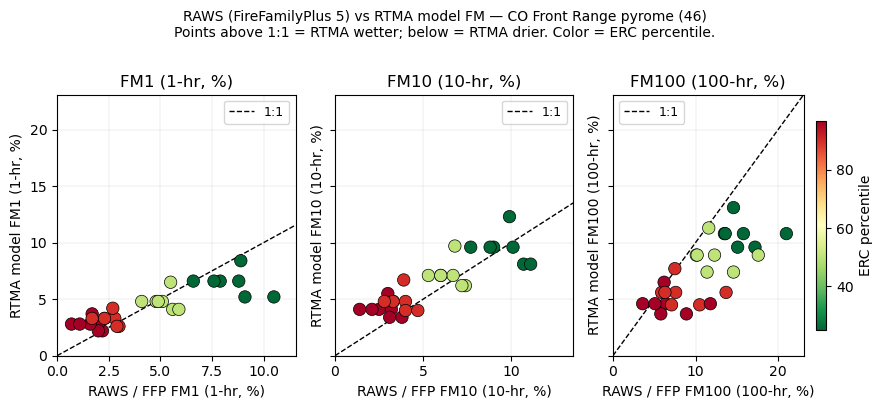

In [33]:
# ── Scatter plot: RAWS FM vs RTMA FM ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(9,4), sharey=True)

var_pairs = [
    ("FM1_raws",   "FM1_rtma",   "FM1 (1-hr, %)",   "#e74c3c"),
    ("FM10_raws",  "FM10_rtma",  "FM10 (10-hr, %)",  "#e67e22"),
    ("FM100_raws", "FM100_rtma", "FM100 (100-hr, %)","#2980b9"),
]

for ax, (xc, yc, title, color) in zip(axes, var_pairs):
    sub = comp[[xc, yc, "erc_pct"]].dropna()
    scatter = ax.scatter(sub[xc], sub[yc], c=sub["erc_pct"],
                          cmap="RdYlGn_r", s=80, edgecolors="k", lw=0.5, zorder=3)
    # 1:1 line
    lim = max(sub[[xc, yc]].max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
    ax.set_xlabel(f"RAWS / FFP {title}")
    ax.set_ylabel(f"RTMA model {title}")
    ax.set_title(title)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.grid(lw=0.3, alpha=0.5)
    ax.legend(fontsize=9)

cbar = fig.colorbar(scatter, ax=axes[-1], shrink=0.8)
cbar.set_label("ERC percentile")
fig.suptitle(
    "RAWS (FireFamilyPlus 5) vs RTMA model FM — CO Front Range pyrome (46)\n"
    "Points above 1:1 = RTMA wetter; below = RTMA drier. Color = ERC percentile.",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig(projdir / 'fig_A_fl_threshold_wetland.png', dpi=300, bbox_inches='tight')
plt.show()